In [1]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path

# Load trained regression model
regression_model = joblib.load(
    "../models/xgb_regression.pkl"
)

# Load regression dataset
df = pd.read_excel(
    "../data/processed/CarbonOpt_XGBoost_Regression.xlsx"
)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())
print("\nRegression model loaded successfully.")

Dataset shape: (3162, 11)
Columns:
['state', 'year', 'residential_billion_btu', 'commercial_billion_btu', 'industrial_billion_btu', 'transportation_billion_btu', 'co2_lag_1', 'co2_lag_2', 'energy_growth_rate', 'co2_growth_rate', 'co2_next_year']

Regression model loaded successfully.


In [2]:
features = [
    "state",
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]

target = "co2_next_year"

print("Features:")
print(features)

print("\nTarget:", target)

Features:
['state', 'year', 'residential_billion_btu', 'commercial_billion_btu', 'industrial_billion_btu', 'transportation_billion_btu', 'co2_lag_1', 'co2_lag_2', 'energy_growth_rate', 'co2_growth_rate']

Target: co2_next_year


In [3]:
controllable_features = [
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu"
]

print(
    df[controllable_features].describe().T
)

                             count           mean            std      min  \
residential_billion_btu     3162.0  327101.593928  320253.184653   7685.0   
commercial_billion_btu      3162.0  249253.806452  273412.577370   5719.0   
industrial_billion_btu      3162.0  590979.757748  892515.635406   3335.0   
transportation_billion_btu  3162.0  438242.976597  498633.953362  16434.0   

                                  25%       50%        75%        max  
residential_billion_btu      79478.25  224585.0  426343.25  1669597.0  
commercial_billion_btu       63343.75  149531.0  327552.00  1555437.0  
industrial_billion_btu      155939.25  361885.5  611905.00  7672800.0  
transportation_billion_btu  131658.50  289749.0  558901.75  3356244.0  


In [5]:
# Predict next-year CO2 for all observations
df["predicted_co2_next_year"] = regression_model.predict(
    df[features]
)

# Find the observation with the highest predicted CO2
target_index = df["predicted_co2_next_year"].idxmax()

target_row = df.loc[target_index].copy()

print("Target observation:")
print(target_row[features])

print("\nActual next-year CO2:",
      target_row["co2_next_year"])

print("Predicted next-year CO2:",
      target_row["predicted_co2_next_year"])

Target observation:
state                               TX
year                              2001
residential_billion_btu        1450183
commercial_billion_btu         1245714
industrial_billion_btu         6556603
transportation_billion_btu     2674517
co2_lag_1                      679.802
co2_lag_2                      653.296
energy_growth_rate           -1.699012
co2_growth_rate              -0.920268
Name: 2705, dtype: object

Actual next-year CO2: 684.268
Predicted next-year CO2: 682.2365


In [6]:
TARGET_REDUCTION = 0.10

baseline_co2 = target_row["predicted_co2_next_year"]

target_co2 = baseline_co2 * (1 - TARGET_REDUCTION)

print("Baseline predicted CO2:", baseline_co2)
print("Target reduction:", TARGET_REDUCTION * 100, "%")
print("Target CO2:", target_co2)

Baseline predicted CO2: 682.2365
Target reduction: 10.0 %
Target CO2: 614.0128


In [7]:
MAX_REDUCTION = 0.20

bounds = [
    (0, MAX_REDUCTION),  # Residential
    (0, MAX_REDUCTION),  # Commercial
    (0, MAX_REDUCTION),  # Industrial
    (0, MAX_REDUCTION)   # Transportation
]

print("Optimization bounds:", bounds)

Optimization bounds: [(0, 0.2), (0, 0.2), (0, 0.2), (0, 0.2)]


In [8]:
def predict_with_reduction(reductions):
    """
    Predict next-year CO2 after applying reductions
    to the four controllable energy variables.

    reductions:
        [residential, commercial, industrial, transportation]
    """

    scenario = target_row[features].copy()

    # Apply percentage reductions
    scenario["residential_billion_btu"] *= (1 - reductions[0])
    scenario["commercial_billion_btu"] *= (1 - reductions[1])
    scenario["industrial_billion_btu"] *= (1 - reductions[2])
    scenario["transportation_billion_btu"] *= (1 - reductions[3])

    # Convert Series to one-row DataFrame
    scenario_df = pd.DataFrame([scenario])

    # Predict using trained XGBoost regression model
    predicted_co2 = regression_model.predict(
        scenario_df
    )[0]

    return predicted_co2

In [9]:
# No intervention
baseline_test = predict_with_reduction(
    [0, 0, 0, 0]
)

# 10% reduction in all four sectors
ten_percent_test = predict_with_reduction(
    [0.10, 0.10, 0.10, 0.10]
)

print("Baseline prediction:", baseline_test)
print("10% all-sector reduction:", ten_percent_test)
print(
    "Predicted reduction:",
    baseline_test - ten_percent_test
)

Baseline prediction: 682.2365
10% all-sector reduction: 663.42487
Predicted reduction: 18.811646


In [10]:
from scipy.optimize import minimize
def objective(reductions):
    """
    Minimize total intervention.
    """
    return np.sum(reductions)


def co2_constraint(reductions):
    """
    Constraint:
    predicted CO2 must be at or below the target.
    """
    predicted_co2 = predict_with_reduction(reductions)

    return target_co2 - predicted_co2

In [12]:
from scipy.optimize import differential_evolution
import numpy as np

def optimization_objective(reductions):

    predicted_co2 = predict_with_reduction(reductions)

    # Total intervention
    total_reduction = np.sum(reductions)

    # Constraint violation
    violation = max(0, predicted_co2 - target_co2)

    # Penalty for not reaching target
    penalty = violation * 1000

    return total_reduction + penalty


result = differential_evolution(
    optimization_objective,
    bounds=bounds,
    seed=42,
    maxiter=200,
    popsize=15,
    tol=1e-7,
    polish=True
)

print("Optimization successful:", result.success)
print("Message:", result.message)
print("Optimal reductions:", result.x)
print("Objective value:", result.fun)

Optimization successful: True
Message: Optimization terminated successfully.
Optimal reductions: [0.19124647 0.01414893 0.12824327 0.11250608]
Objective value: 28295.55161349827


In [13]:
optimal_reductions = result.x

optimized_co2 = predict_with_reduction(optimal_reductions)

print("\n--- OPTIMIZATION RESULT ---")

print("Residential reduction:",
      optimal_reductions[0] * 100, "%")

print("Commercial reduction:",
      optimal_reductions[1] * 100, "%")

print("Industrial reduction:",
      optimal_reductions[2] * 100, "%")

print("Transportation reduction:",
      optimal_reductions[3] * 100, "%")

print("\nBaseline predicted CO2:",
      baseline_co2)

print("Target CO2:",
      target_co2)

print("Optimized predicted CO2:",
      optimized_co2)

print("CO2 reduction:",
      baseline_co2 - optimized_co2)

print("Total intervention:",
      np.sum(optimal_reductions) * 100, "%")


--- OPTIMIZATION RESULT ---
Residential reduction: 19.12464707953582 %
Commercial reduction: 1.4148926774892794 %
Industrial reduction: 12.824326692085968 %
Transportation reduction: 11.25060837801573 %

Baseline predicted CO2: 682.2365
Target CO2: 614.0128
Optimized predicted CO2: 642.3079
CO2 reduction: 39.92859
Total intervention: 44.6144748271268 %


In [14]:
max_reduction = [0.20, 0.20, 0.20, 0.20]

max_reduction_prediction = predict_with_reduction(max_reduction)

print("Baseline CO2:", baseline_co2)
print("Target CO2:", target_co2)
print("20% reduction in all sectors:", max_reduction_prediction)

print(
    "Reduction achieved:",
    baseline_co2 - max_reduction_prediction
)

Baseline CO2: 682.2365
Target CO2: 614.0128
20% reduction in all sectors: 642.7188
Reduction achieved: 39.5177


In [15]:
maximum_reduction = baseline_co2 - max_reduction_prediction
maximum_reduction_percent = (
    maximum_reduction / baseline_co2
) * 100

print("Maximum achievable CO2 reduction:",
      maximum_reduction)

print("Maximum achievable reduction (%):",
      maximum_reduction_percent)

Maximum achievable CO2 reduction: 39.5177
Maximum achievable reduction (%): 5.792375


In [16]:
TARGET_REDUCTION = maximum_reduction / baseline_co2

target_co2 = baseline_co2 * (1 - TARGET_REDUCTION)

print("Feasible target reduction:",
      TARGET_REDUCTION * 100, "%")

print("Target CO2:",
      target_co2)

Feasible target reduction: 5.792375 %
Target CO2: 642.7188


In [1]:
from scipy.optimize import differential_evolution, NonlinearConstraint

def optimization_objective(reductions):
    """
    Minimize total percentage intervention.
    """
    return np.sum(reductions)


def target_constraint(reductions):
    """
    Predicted CO2 must be <= target CO2.
    """
    predicted = predict_with_reduction(reductions)
    return target_co2 - predicted


constraint = NonlinearConstraint(
    target_constraint,
    0,
    np.inf
)


result = differential_evolution(
    optimization_objective,
    bounds=bounds,
    constraints=(constraint,),
    seed=42,
    maxiter=300,
    popsize=20,
    tol=1e-8,
    polish=True
)

print("Optimization successful:", result.success)
print("Message:", result.message)
print("Optimal reductions:", result.x)
print("Total intervention:", np.sum(result.x) * 100, "%")

NameError: name 'np' is not defined

In [2]:
import numpy as np
from scipy.optimize import differential_evolution, NonlinearConstraint
def optimization_objective(reductions):
    return np.sum(reductions)


def target_constraint(reductions):
    predicted = predict_with_reduction(reductions)
    return target_co2 - predicted


constraint = NonlinearConstraint(
    target_constraint,
    0,
    np.inf
)


result = differential_evolution(
    optimization_objective,
    bounds=bounds,
    constraints=(constraint,),
    seed=42,
    maxiter=300,
    popsize=20,
    tol=1e-8,
    polish=True
)

print("Optimization successful:", result.success)
print("Message:", result.message)
print("Optimal reductions:", result.x)
print("Total intervention:", np.sum(result.x) * 100, "%")

NameError: name 'bounds' is not defined

In [3]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path
from scipy.optimize import differential_evolution, NonlinearConstraint


# ==========================================
# 1. LOAD MODEL AND DATA
# ==========================================

regression_model = joblib.load(
    "../models/xgb_regression.pkl"
)

df = pd.read_excel(
    "../data/processed/CarbonOpt_XGBoost_Regression.xlsx"
)


# ==========================================
# 2. DEFINE FEATURES
# ==========================================

features = [
    "state",
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]


# ==========================================
# 3. PREDICT BASELINE CO2
# ==========================================

df["predicted_co2_next_year"] = regression_model.predict(
    df[features]
)

target_index = df["predicted_co2_next_year"].idxmax()

target_row = df.loc[target_index].copy()

baseline_co2 = target_row["predicted_co2_next_year"]

print("Selected scenario:")
print("State:", target_row["state"])
print("Year:", target_row["year"])
print("Baseline predicted CO2:", baseline_co2)


# ==========================================
# 4. DEFINE 20% SECTOR REDUCTION BOUNDS
# ==========================================

MAX_REDUCTION = 0.20

bounds = [
    (0, MAX_REDUCTION),  # Residential
    (0, MAX_REDUCTION),  # Commercial
    (0, MAX_REDUCTION),  # Industrial
    (0, MAX_REDUCTION)   # Transportation
]


# ==========================================
# 5. PREDICTION FUNCTION
# ==========================================

def predict_with_reduction(reductions):

    scenario = target_row[features].copy()

    scenario["residential_billion_btu"] *= (
        1 - reductions[0]
    )

    scenario["commercial_billion_btu"] *= (
        1 - reductions[1]
    )

    scenario["industrial_billion_btu"] *= (
        1 - reductions[2]
    )

    scenario["transportation_billion_btu"] *= (
        1 - reductions[3]
    )

    scenario_df = pd.DataFrame([scenario])

    predicted_co2 = regression_model.predict(
        scenario_df
    )[0]

    return predicted_co2


# ==========================================
# 6. CHECK MAXIMUM FEASIBLE REDUCTION
# ==========================================

maximum_reduction_vector = [
    0.20,
    0.20,
    0.20,
    0.20
]

max_reduction_prediction = predict_with_reduction(
    maximum_reduction_vector
)

maximum_reduction = (
    baseline_co2 - max_reduction_prediction
)

maximum_reduction_percent = (
    maximum_reduction / baseline_co2
) * 100


print("\nMaximum feasible scenario:")
print(
    "20% reduction in all sectors:",
    max_reduction_prediction
)

print(
    "Maximum CO2 reduction:",
    maximum_reduction
)

print(
    "Maximum reduction (%):",
    maximum_reduction_percent
)


# ==========================================
# 7. DEFINE FEASIBLE TARGET
# ==========================================

TARGET_REDUCTION = (
    maximum_reduction / baseline_co2
)

target_co2 = (
    baseline_co2 * (1 - TARGET_REDUCTION)
)

print("\nOptimization target:")
print("Target reduction:", TARGET_REDUCTION * 100, "%")
print("Target CO2:", target_co2)

Selected scenario:
State: TX
Year: 2001
Baseline predicted CO2: 682.2365

Maximum feasible scenario:
20% reduction in all sectors: 642.7188
Maximum CO2 reduction: 39.5177
Maximum reduction (%): 5.792375

Optimization target:
Target reduction: 5.792375 %
Target CO2: 642.7188


In [1]:
def optimization_objective(reductions):
    return np.sum(reductions)


def target_constraint(reductions):
    predicted = predict_with_reduction(reductions)
    return target_co2 - predicted


constraint = NonlinearConstraint(
    target_constraint,
    0,
    np.inf
)


result = differential_evolution(
    optimization_objective,
    bounds=bounds,
    constraints=(constraint,),
    seed=42,
    maxiter=300,
    popsize=20,
    tol=1e-8,
    polish=True
)


print("Optimization successful:", result.success)
print("Message:", result.message)
print("Optimal reductions:", result.x)
print(
    "Total intervention:",
    np.sum(result.x) * 100,
    "%"
)

NameError: name 'NonlinearConstraint' is not defined

In [2]:
# ==========================================
# CARBONOPT - COMPLETE OPTIMIZATION CELL
# ==========================================

import pandas as pd
import numpy as np
import joblib

from scipy.optimize import differential_evolution
from scipy.optimize import NonlinearConstraint


# 1. LOAD MODEL
regression_model = joblib.load(
    "../models/xgb_regression.pkl"
)

# 2. LOAD DATA
df = pd.read_excel(
    "../data/processed/CarbonOpt_XGBoost_Regression.xlsx"
)

# 3. FEATURES
features = [
    "state",
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]

# 4. FIND HIGHEST-PREDICTED-CO2 SCENARIO
df["predicted_co2_next_year"] = regression_model.predict(
    df[features]
)

target_index = df["predicted_co2_next_year"].idxmax()
target_row = df.loc[target_index].copy()

baseline_co2 = target_row["predicted_co2_next_year"]

print("Selected scenario")
print("-----------------")
print("State:", target_row["state"])
print("Year:", target_row["year"])
print("Baseline predicted CO2:", baseline_co2)


# 5. PREDICTION FUNCTION
def predict_with_reduction(reductions):

    scenario = target_row[features].copy()

    scenario["residential_billion_btu"] *= (
        1 - reductions[0]
    )

    scenario["commercial_billion_btu"] *= (
        1 - reductions[1]
    )

    scenario["industrial_billion_btu"] *= (
        1 - reductions[2]
    )

    scenario["transportation_billion_btu"] *= (
        1 - reductions[3]
    )

    scenario_df = pd.DataFrame([scenario])

    return regression_model.predict(
        scenario_df
    )[0]


# 6. SECTOR REDUCTION BOUNDS
MAX_REDUCTION = 0.20

bounds = [
    (0, MAX_REDUCTION),
    (0, MAX_REDUCTION),
    (0, MAX_REDUCTION),
    (0, MAX_REDUCTION)
]


# 7. MAXIMUM FEASIBLE SCENARIO
maximum_reduction_vector = [
    0.20,
    0.20,
    0.20,
    0.20
]

max_reduction_prediction = predict_with_reduction(
    maximum_reduction_vector
)

maximum_reduction = (
    baseline_co2 - max_reduction_prediction
)

TARGET_REDUCTION = (
    maximum_reduction / baseline_co2
)

target_co2 = (
    baseline_co2 * (1 - TARGET_REDUCTION)
)

print("\nFeasibility check")
print("-----------------")
print(
    "20% reduction in all sectors:",
    max_reduction_prediction
)

print(
    "Maximum CO2 reduction:",
    maximum_reduction
)

print(
    "Maximum reduction (%):",
    TARGET_REDUCTION * 100
)

print(
    "Optimization target CO2:",
    target_co2
)


# 8. OBJECTIVE
def optimization_objective(reductions):

    # Minimize total intervention
    return np.sum(reductions)


# 9. CONSTRAINT
def target_constraint(reductions):

    predicted = predict_with_reduction(
        reductions
    )

    return target_co2 - predicted


constraint = NonlinearConstraint(
    target_constraint,
    0,
    np.inf
)


# 10. OPTIMIZATION
print("\nRunning optimizer...")

result = differential_evolution(
    optimization_objective,
    bounds=bounds,
    constraints=(constraint,),
    seed=42,
    maxiter=100,
    popsize=10,
    tol=1e-5,
    polish=False,
    workers=1
)


# 11. FINAL RESULTS
optimal_reductions = result.x

optimized_co2 = predict_with_reduction(
    optimal_reductions
)

print("\n==============================")
print("OPTIMIZATION RESULT")
print("==============================")

print(
    "Optimization successful:",
    result.success
)

print(
    "Message:",
    result.message
)

print(
    "\nResidential reduction:",
    optimal_reductions[0] * 100,
    "%"
)

print(
    "Commercial reduction:",
    optimal_reductions[1] * 100,
    "%"
)

print(
    "Industrial reduction:",
    optimal_reductions[2] * 100,
    "%"
)

print(
    "Transportation reduction:",
    optimal_reductions[3] * 100,
    "%"
)

print(
    "\nBaseline predicted CO2:",
    baseline_co2
)

print(
    "Target CO2:",
    target_co2
)

print(
    "Optimized predicted CO2:",
    optimized_co2
)

print(
    "Predicted CO2 reduction:",
    baseline_co2 - optimized_co2
)

print(
    "Predicted reduction (%):",
    (
        (baseline_co2 - optimized_co2)
        / baseline_co2
    ) * 100
)

print(
    "Total intervention:",
    np.sum(optimal_reductions) * 100,
    "%"
)

print(
    "Target satisfied:",
    optimized_co2 <= target_co2
)

Selected scenario
-----------------
State: TX
Year: 2001
Baseline predicted CO2: 682.2365

Feasibility check
-----------------
20% reduction in all sectors: 642.7188
Maximum CO2 reduction: 39.5177
Maximum reduction (%): 5.792375
Optimization target CO2: 642.7188

Running optimizer...

OPTIMIZATION RESULT
Optimization successful: False
Message: Maximum number of iterations has been exceeded.

Residential reduction: 17.00118631224913 %
Commercial reduction: 1.393539762410212 %
Industrial reduction: 12.794146788743582 %
Transportation reduction: 11.247466515434677 %

Baseline predicted CO2: 682.2365
Target CO2: 642.7188
Optimized predicted CO2: 642.51605
Predicted CO2 reduction: 39.72046
Predicted reduction (%): 5.8220954
Total intervention: 42.4363393788376 %
Target satisfied: True


In [1]:
print("Optimization successful:", result.success)
print("Message:", result.message)
print("Optimal reductions:", result.x)

optimized_co2 = predict_with_reduction(result.x)

print("Optimized CO2:", optimized_co2)
print("Target CO2:", target_co2)
print("Target satisfied:", optimized_co2 <= target_co2)
print("Total intervention:", np.sum(result.x) * 100, "%")

NameError: name 'result' is not defined

In [2]:
result = differential_evolution(
    optimization_objective,
    bounds=bounds,
    constraints=(constraint,),
    seed=42,
    maxiter=500,
    popsize=15,
    tol=1e-7,
    polish=False,
    workers=1
)

NameError: name 'differential_evolution' is not defined

In [3]:
from scipy.optimize import differential_evolution, NonlinearConstraint

In [4]:
result = differential_evolution(
    optimization_objective,
    bounds=bounds,
    constraints=(constraint,),
    seed=42,
    maxiter=500,
    popsize=15,
    tol=1e-7,
    polish=False,
    workers=1
)

NameError: name 'optimization_objective' is not defined

In [5]:
import pandas as pd
import numpy as np
import joblib

from scipy.optimize import differential_evolution, NonlinearConstraint

# =========================================================
# 1. LOAD MODEL + DATA
# =========================================================

regression_model = joblib.load("../models/xgb_regression.pkl")

df = pd.read_excel(
    "../data/processed/CarbonOpt_XGBoost_Regression.xlsx"
)

features = [
    "state",
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]

# =========================================================
# 2. SELECT HIGHEST-EMISSION SCENARIO
# =========================================================

predictions = regression_model.predict(df[features])

target_index = predictions.argmax()

target_row = df.iloc[target_index].copy()

baseline_co2 = predictions[target_index]

print("Target scenario:")
print("State:", target_row["state"])
print("Year:", target_row["year"])
print("Baseline predicted CO2:", baseline_co2)

# =========================================================
# 3. PREDICTION FUNCTION
# =========================================================

def predict_with_reduction(reductions):

    scenario = target_row[features].copy()

    scenario["residential_billion_btu"] *= (1 - reductions[0])
    scenario["commercial_billion_btu"] *= (1 - reductions[1])
    scenario["industrial_billion_btu"] *= (1 - reductions[2])
    scenario["transportation_billion_btu"] *= (1 - reductions[3])

    scenario_df = pd.DataFrame([scenario])

    return regression_model.predict(scenario_df)[0]


# =========================================================
# 4. BOUNDS
# =========================================================

bounds = [
    (0.0, 0.20),   # Residential
    (0.0, 0.20),   # Commercial
    (0.0, 0.20),   # Industrial
    (0.0, 0.20)    # Transportation
]

# =========================================================
# 5. FIND MAXIMUM FEASIBLE CO2 REDUCTION
# =========================================================

maximum_reduction_vector = np.array([
    0.20,
    0.20,
    0.20,
    0.20
])

maximum_co2 = predict_with_reduction(
    maximum_reduction_vector
)

maximum_reduction = baseline_co2 - maximum_co2

maximum_reduction_pct = (
    maximum_reduction / baseline_co2
)

target_co2 = maximum_co2

print("\nMaximum feasible scenario:")
print("CO2:", maximum_co2)
print("Reduction:", maximum_reduction)
print("Reduction (%):", maximum_reduction_pct * 100)

# =========================================================
# 6. OBJECTIVE FUNCTION
# =========================================================

def optimization_objective(reductions):
    return np.sum(reductions)


# =========================================================
# 7. CONSTRAINT
# =========================================================

def target_constraint(reductions):

    predicted_co2 = predict_with_reduction(reductions)

    return target_co2 - predicted_co2


constraint = NonlinearConstraint(
    target_constraint,
    0,
    np.inf
)

# =========================================================
# 8. RUN DIFFERENTIAL EVOLUTION
# =========================================================

print("\nRunning optimization...")

result = differential_evolution(
    optimization_objective,
    bounds=bounds,
    constraints=(constraint,),
    seed=42,
    maxiter=500,
    popsize=15,
    tol=1e-7,
    polish=False,
    workers=1
)

# =========================================================
# 9. FINAL RESULTS
# =========================================================

optimal_reductions = result.x

optimized_co2 = predict_with_reduction(
    optimal_reductions
)

co2_reduction = baseline_co2 - optimized_co2

co2_reduction_pct = (
    co2_reduction / baseline_co2
) * 100

total_intervention = (
    np.sum(optimal_reductions) * 100
)

print("\n========================================")
print("CARBONOPT OPTIMIZATION RESULTS")
print("========================================")

print("\nOptimization successful:")
print(result.success)

print("\nMessage:")
print(result.message)

print("\nSector reductions:")

print(
    "Residential:",
    round(optimal_reductions[0] * 100, 4),
    "%"
)

print(
    "Commercial:",
    round(optimal_reductions[1] * 100, 4),
    "%"
)

print(
    "Industrial:",
    round(optimal_reductions[2] * 100, 4),
    "%"
)

print(
    "Transportation:",
    round(optimal_reductions[3] * 100, 4),
    "%"
)

print("\nBaseline predicted CO2:")
print(round(baseline_co2, 4), "Mt")

print("\nOptimized predicted CO2:")
print(round(optimized_co2, 4), "Mt")

print("\nTarget CO2:")
print(round(target_co2, 4), "Mt")

print("\nPredicted CO2 reduction:")
print(round(co2_reduction, 4), "Mt")

print("\nPredicted reduction (%):")
print(round(co2_reduction_pct, 4), "%")

print("\nTotal intervention:")
print(round(total_intervention, 4), "%")

print("\nTarget satisfied:")
print(optimized_co2 <= target_co2)

print("\n========================================")

Target scenario:
State: TX
Year: 2001
Baseline predicted CO2: 682.2365

Maximum feasible scenario:
CO2: 642.7188
Reduction: 39.5177
Reduction (%): 5.792375

Running optimization...

CARBONOPT OPTIMIZATION RESULTS

Optimization successful:
True

Message:
Optimization terminated successfully.

Sector reductions:
Residential: 17.0012 %
Commercial: 1.3934 %
Industrial: 12.7941 %
Transportation: 11.2475 %

Baseline predicted CO2:
682.2365 Mt

Optimized predicted CO2:
642.516 Mt

Target CO2:
642.7188 Mt

Predicted CO2 reduction:
39.7205 Mt

Predicted reduction (%):
5.8221 %

Total intervention:
42.4362 %

Target satisfied:
True



In [6]:
result = differential_evolution(
    optimization_objective,
    bounds=bounds,
    constraints=(constraint,),
    seed=42,
    maxiter=500,
    popsize=15,
    tol=1e-7,
    polish=False,
    workers=1
)

In [7]:
print("Optimization successful:", result.success)
print("Message:", result.message)
print("Optimal reductions:", result.x)

optimized_co2 = predict_with_reduction(result.x)

print("Optimized CO2:", optimized_co2)
print("Target CO2:", target_co2)
print("Target satisfied:", optimized_co2 <= target_co2)
print("Total intervention:", np.sum(result.x) * 100, "%")

Optimization successful: True
Message: Optimization terminated successfully.
Optimal reductions: [0.17001169 0.01393424 0.12794114 0.11247456]
Optimized CO2: 642.51605
Target CO2: 642.7188
Target satisfied: True
Total intervention: 42.436163464444604 %


In [8]:
# ============================================
# SAVE CARBONOPT OPTIMIZATION RESULTS
# ============================================

import os
import pandas as pd

os.makedirs("../outputs/optimization", exist_ok=True)

optimization_results = pd.DataFrame({
    "state": [target_row["state"]],
    "year": [target_row["year"]],

    "baseline_predicted_co2_mt": [baseline_co2],

    "residential_reduction_pct": [
        optimal_reductions[0] * 100
    ],

    "commercial_reduction_pct": [
        optimal_reductions[1] * 100
    ],

    "industrial_reduction_pct": [
        optimal_reductions[2] * 100
    ],

    "transportation_reduction_pct": [
        optimal_reductions[3] * 100
    ],

    "optimized_predicted_co2_mt": [
        optimized_co2
    ],

    "co2_reduction_mt": [
        co2_reduction
    ],

    "co2_reduction_pct": [
        co2_reduction_pct
    ],

    "total_intervention_score_pct": [
        total_intervention
    ],

    "target_co2_mt": [
        target_co2
    ],

    "target_satisfied": [
        optimized_co2 <= target_co2
    ]
})

output_path = "../outputs/optimization/carbonopt_optimization_result.xlsx"

optimization_results.to_excel(
    output_path,
    index=False
)

print("Optimization result saved successfully:")
print(output_path)

optimization_results

Optimization result saved successfully:
../outputs/optimization/carbonopt_optimization_result.xlsx


,state,year,baseline_predicted_co2_mt,residential_reduction_pct,commercial_reduction_pct,industrial_reduction_pct,transportation_reduction_pct,optimized_predicted_co2_mt,co2_reduction_mt,co2_reduction_pct,total_intervention_score_pct,target_co2_mt,target_satisfied
0,TX,2001,682.236511,17.001169,1.393424,12.794114,11.247456,642.516052,39.720459,5.822095,42.436163,642.718811,True


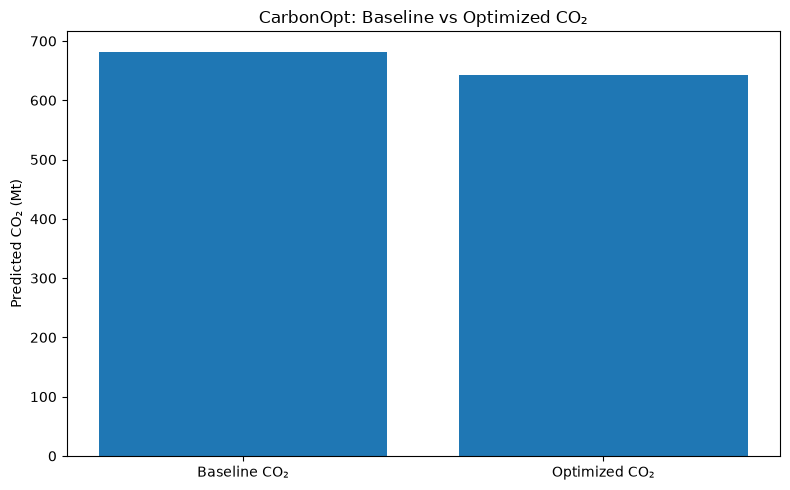

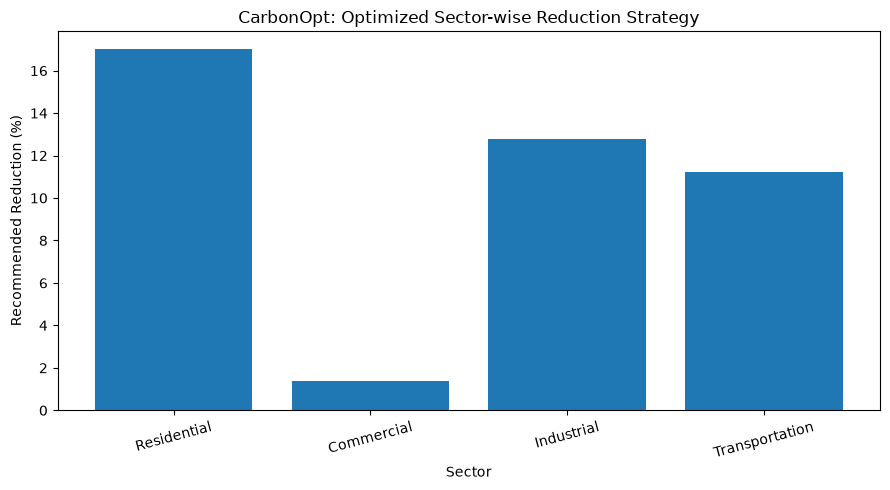

Both optimization plots saved successfully.


In [9]:
# ============================================
# CARBONOPT - FINAL OPTIMIZATION VISUALIZATIONS
# ============================================

import os
import matplotlib.pyplot as plt

os.makedirs("../outputs/optimization", exist_ok=True)

# --------------------------------------------
# 1. Baseline vs Optimized CO2
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    ["Baseline CO₂", "Optimized CO₂"],
    [baseline_co2, optimized_co2]
)

plt.ylabel("Predicted CO₂ (Mt)")
plt.title("CarbonOpt: Baseline vs Optimized CO₂")

plt.tight_layout()

plt.savefig(
    "../outputs/optimization/baseline_vs_optimized_co2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------
# 2. Sector-wise Recommended Reductions
# --------------------------------------------

sectors = [
    "Residential",
    "Commercial",
    "Industrial",
    "Transportation"
]

reductions_pct = [
    optimal_reductions[0] * 100,
    optimal_reductions[1] * 100,
    optimal_reductions[2] * 100,
    optimal_reductions[3] * 100
]

plt.figure(figsize=(9, 5))

plt.bar(
    sectors,
    reductions_pct
)

plt.ylabel("Recommended Reduction (%)")
plt.xlabel("Sector")
plt.title("CarbonOpt: Optimized Sector-wise Reduction Strategy")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../outputs/optimization/sector_reduction_strategy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("Both optimization plots saved successfully.")